# 1. Knowledge graph를 triple 리스트로 저장
### -> 리스트 안에 튜플을 넣는 방식

In [23]:
triples = [
    ("Excavation", "mayCause", "SafetyRisk"),
    ("Excavation", "mayCause", "Delay"),

    ("ConcretePouring", "mayCause", "QualityIssue"),
    ("ConcretePouring", "mayCause", "WeatherImpact"),

    ("CurtainWallInstallation", "mayCause", "Delay"),
    ("CurtainWallInstallation", "mayCause", "MaterialShortage"),
    ("CurtainWallInstallation", "mayCause", "SafetyRisk"),

    ("SafetyRisk", "solvedBy", "InstallSafetyNet"),
    ("Delay", "solvedBy", "IncreaseLabor"),
    ("Delay", "solvedBy", "RescheduleWork"),
    ("QualityIssue", "solvedBy", "AdditionalInspection"),
    ("WeatherImpact", "solvedBy", "RescheduleWork"),
    ("MaterialShortage", "solvedBy", "ExpediteDelivery"),
]

# 2. subject - relation 을 통해 object 찾기

In [24]:
def find_objects(subject, relation, triples):
    results = []
    for s, r, o in triples:
        if s == subject and r == relation:
            results.append(o)
    return results

# 3. Activate -> Issue

In [25]:
def get_issues(activity, triples):
    return find_objects(activity, "mayCause", triples)

# 4. Issue -> Action

In [26]:
def get_actions(issue, triples):
    return find_objects(issue, "solvedBy", triples)

# 5. Activity -> Issue -> Action

In [27]:
def get_actions_for_activity(activity, triples):
    issues = get_issues(activity, triples)
    actions = []

    for issue in issues:
        issue_actions = get_actions(issue, triples)
        actions.extend(issue_actions)

    actions = list(set(actions))
    return issues, actions

# 6. Practice

In [28]:
activity_name = "CurtainWallInstallation"

issues, actions = get_actions_for_activity(activity_name, triples)

print(f"Activity: {activity_name}")
print("Possible Issues:")
for issue in issues:
    print("-", issue)

print("\nRecommended Actions:")
for action in actions:
    print("-", action)

Activity: CurtainWallInstallation
Possible Issues:
- Delay
- MaterialShortage
- SafetyRisk

Recommended Actions:
- IncreaseLabor
- ExpediteDelivery
- InstallSafetyNet
- RescheduleWork


# 7. Visualization

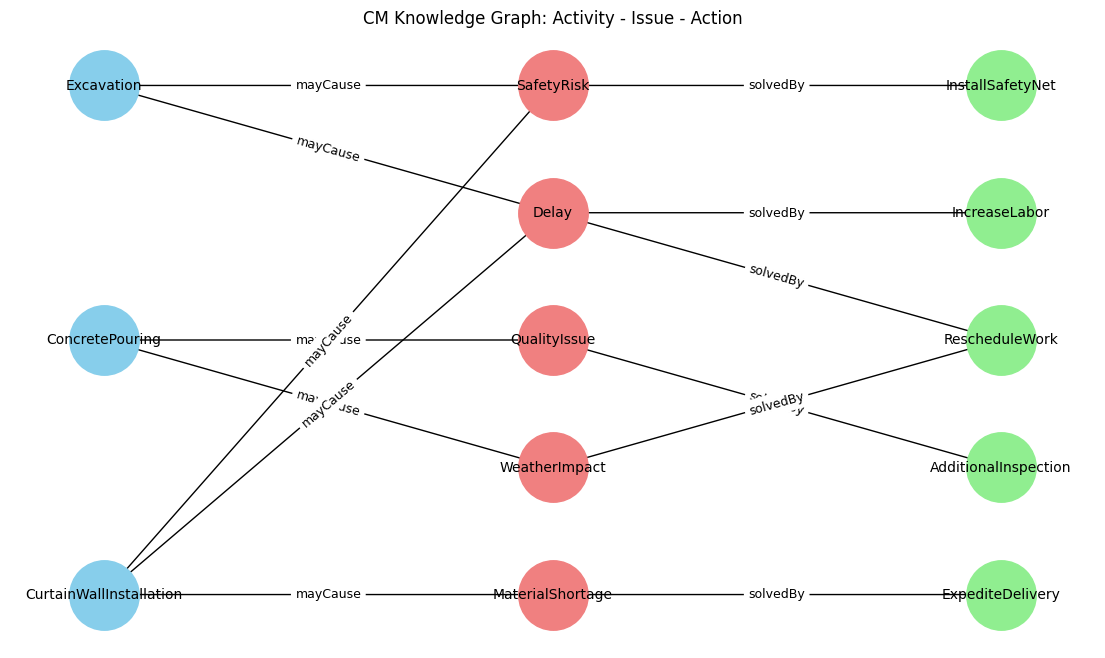

In [32]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

for s, r, o in triples:
    G.add_edge(s, o, label=r)

activities = ["Excavation", "ConcretePouring", "CurtainWallInstallation"]
issues = ["SafetyRisk", "Delay", "QualityIssue", "WeatherImpact", "MaterialShortage"]
actions = ["InstallSafetyNet", "IncreaseLabor", "RescheduleWork", "AdditionalInspection", "ExpediteDelivery"]

pos = {
    "Excavation": (0, 2),
    "ConcretePouring": (0, 1),
    "CurtainWallInstallation": (0, 0),

    "SafetyRisk": (2, 2),
    "Delay": (2, 1.5),
    "QualityIssue": (2, 1),
    "WeatherImpact": (2, 0.5),
    "MaterialShortage": (2, 0),

    "InstallSafetyNet": (4, 2),
    "IncreaseLabor": (4, 1.5),
    "RescheduleWork": (4, 1),
    "AdditionalInspection": (4, 0.5),
    "ExpediteDelivery": (4, 0),
}

plt.figure(figsize=(14, 8))

nx.draw_networkx_nodes(G, pos, nodelist=activities, node_color="skyblue", node_size=2500)
nx.draw_networkx_nodes(G, pos, nodelist=issues, node_color="lightcoral", node_size=2500)
nx.draw_networkx_nodes(G, pos, nodelist=actions, node_color="lightgreen", node_size=2500)

nx.draw_networkx_labels(G, pos, font_size=10, font_color="black")

nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle="->", arrowsize=20)

edge_labels = {(u, v): d["label"] for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9)

plt.title("CM Knowledge Graph: Activity - Issue - Action")
plt.axis("off")
plt.show()

# 8. Rule-Based-Reasoning 추가하기